In [ ]:
from google.colab import files
uploaded = files.upload()

Saving crop_loan_dataset_realistic.xlsx to crop_loan_dataset_realistic.xlsx


Performing 5-fold Cross-Validation...

Cross-Validated Accuracy: 0.789
Cross-Validated Precision: 0.8269896193771626
Cross-Validated Confusion Matrix:
 [[311 100]
 [111 478]]


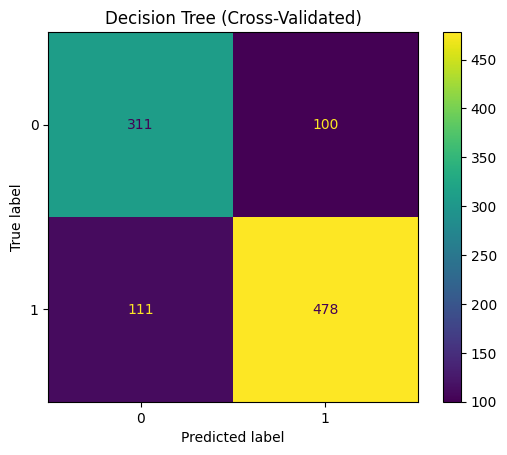

In [ ]:
# ============================================================
# Step 1: Import Libraries
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import KFold, cross_val_predict, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, precision_score
import numpy as np


# ============================================================
# Step 2: Load Dataset
# ============================================================


df = pd.read_excel("crop_loan_dataset_realistic.xlsx")

df.head()


# ============================================================
# Step 3: Data Preprocessing
# ============================================================

df = df.drop(columns=["Application_ID"])

le = LabelEncoder()
for col in df.columns:
    df[col] = le.fit_transform(df[col])


# ============================================================
# Step 4: Split Data (for cross-validation, we define X and y)
# ============================================================

X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

# ============================================================
# Step 5: Initialize Decision Tree Model
# ============================================================

model = DecisionTreeClassifier(random_state=42)

# ============================================================
# Step 6: Cross-Validation
# ============================================================

print("Performing 5-fold Cross-Validation...")

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Get cross-validated predictions
y_pred_cv = cross_val_predict(model, X, y, cv=kf)

# ============================================================
# Step 7: Cross-Validated Evaluation
# ============================================================

# Cross-validated Accuracy
accuracy_cv = accuracy_score(y, y_pred_cv)
print("\nCross-Validated Accuracy:", accuracy_cv)

# Cross-validated Precision
precision_cv = precision_score(y, y_pred_cv)
print("Cross-Validated Precision:", precision_cv)

# Cross-validated Confusion Matrix
cm_cv = confusion_matrix(y, y_pred_cv)
print("Cross-Validated Confusion Matrix:\n", cm_cv)

ConfusionMatrixDisplay.from_predictions(y, y_pred_cv)
plt.title("Decision Tree (Cross-Validated)")
plt.show()


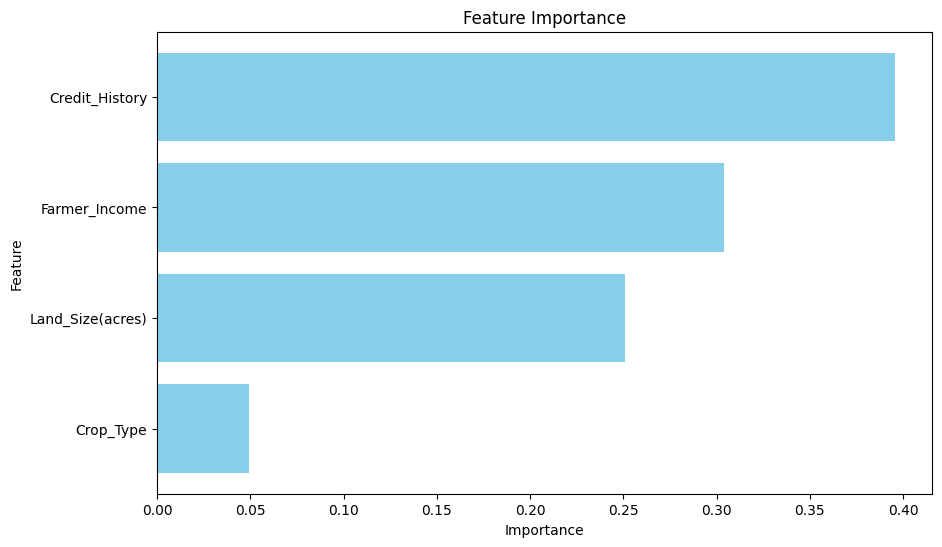

In [ ]:
# ============================================================
# Feature Importance Plot
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# Fit the model to the entire dataset to get feature importances
model.fit(X, y)

# Get feature importances from the model
feature_importances = model.feature_importances_

# Create a DataFrame for better visualization
features_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
})

# Sort features by importance
features_df = features_df.sort_values(by='Importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.barh(features_df['Feature'], features_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance')
plt.gca().invert_yaxis() # Invert y-axis to have the most important feature at the top
plt.show()